# Fisher Information Analysis and Model Cross-Fitting

Code used to run analysis and generate plots for "Mitigating effects of jitter through differentiable
forwards-modeling for the TOLIMAN space telescope".

In [1]:
import os

import jax
from jax import numpy as np, random as jr, Array
import zodiax as zdx
import dLux as dl
import dLuxToliman as dlT

# Enable 64bit precision (note this must be run in the first cell of the notebook)
jax.config.update("jax_enable_x64", True)

import optax
from tqdm.notebook import tqdm
import random
from datetime import datetime

# plotting
import matplotlib as mpl
from matplotlib import pyplot as plt
import scienceplots
import cmasher as cmr

plt.style.use(["science", "no-latex"])
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300

# Colour schemes
ito_seven = [
    "#0072B2",
    "#D55E00",
    "#009E73",
    "#CC79A7",
    "#56B4E9",
    "#E69F00",
    "#F0E442",
]
contrast_three = ["#004488", "#BB5566", "#DDAA33"]

In [2]:
# Set to True if you want to run the computation
# Set to False if you want to load the pre-calculated results from disk
run_compute = True

Setting up the model.

In [4]:
from dLuxToliman.layers.detector_layers import BaseJitter
import dLux.utils as dlu
from jax.scipy.stats import multivariate_normal


class GaussianJitter(BaseJitter):
    """
    Convolves the image with a multivariate Gaussian kernel parameterised by the
    magnitude, shear and angle.

    Attributes
    ----------
    kernel_size : int
        The size in pixels of the convolution kernel to use.
    r : float, arcseconds
        The magnitude of the jitter.
    shear : float
        The shear of the jitter.
    phi : float, degrees
        The angle of the jitter.
    kernel_size : int, odd
        The size of the convolution kernel in pixels to use.
    kernel_oversample : int
        The oversampling factor for the kernel generation.
    """

    r: float | Array
    shear: float | Array = None
    phi: float | Array = None
    kernel_oversample: int

    def __init__(
        self: BaseJitter,
        r: float | Array,
        shear: float | Array = 0,
        phi: float | Array = 0,
        kernel_size: int = 11,
        kernel_oversample: int = 1,
    ):
        """
        Constructor for the ApplyJitter class.

        Parameters
        ----------
        r : float
            The jitter magnitude, defined as the determinant of the covariance
            matrix of the multivariate Gaussian kernel. This is the product of the
            standard deviations of the minor and major axes of the kernel, given in
            arcseconds.
        shear : float, [0, 1)
            A measure of how asymmetric the jitter is. Defined as one minus the ratio between
            the standard deviations of the minor/major axes of the multivariate
            Gaussian kernel. It must lie on the interval [0, 1). A shear of 0
            corresponds to a symmetric jitter, while as shear approaches one the
            jitter kernel becomes more linear.
        phi : float
            The angle of the jitter in degrees.
        kernel_size : int = 10
            The size of the convolution kernel in pixels to use.
        """

        # checking for odd kernel size
        if kernel_size % 2 == 0:
            raise ValueError("kernel_size must be an odd integer")

        # checking shear is valid
        if shear >= 1 or shear < 0:
            raise ValueError("shear must lie on the interval [0, 1)")

        super().__init__(kernel_size)

        self.r = np.array(r)
        self.shear = np.array(shear)
        self.phi = np.array(phi)
        self.kernel_oversample = kernel_oversample

    @property
    def covariance_matrix(self):
        """
        Generates the covariance matrix for the multivariate normal distribution.

        Returns
        -------
        covariance_matrix : Array
            The covariance matrix.
        """
        # Compute the rotation angle
        rot_angle = np.radians(self.phi)

        # Construct the rotation matrix
        R = np.array(
            [
                [np.cos(rot_angle), -np.sin(rot_angle)],
                [np.sin(rot_angle), np.cos(rot_angle)],
            ]
        )

        # calculating the variances (var1 > var2)
        var1 = 1e-3 * np.sqrt(self.r) / (1 - self.shear)
        var2 = var1 * (1 - self.shear) ** 2

        # Construct the skew matrix
        base_matrix = np.array(
            [
                [var1, 0],
                [0, var2],
            ]
        )

        # Compute the covariance matrix
        covariance_matrix = np.dot(np.dot(R, base_matrix), R.T)

        return covariance_matrix

    def generate_kernel(self, pixel_scale: float) -> Array:
        """
        Generates the normalised multivariate Gaussian kernel.

        Parameters
        ----------
        pixel_scale : float
            The pixel scale of the image in arcseconds per pixel.

        Returns
        -------
        kernel : Array
            The normalised Gaussian kernel.
        """
        # Generate distribution
        extent = pixel_scale * self.kernel_size  # kernel size in arcseconds
        x = (
            np.linspace(0, extent, self.kernel_oversample * self.kernel_size)
            - 0.5 * extent
        )
        xs, ys = np.meshgrid(x, x)
        pos = np.dstack((xs, ys))

        kernel = dlu.downsample(
            multivariate_normal.pdf(
                pos, mean=np.array([0.0, 0.0]), cov=self.covariance_matrix
            ),
            self.kernel_oversample,
        )

        return kernel / np.sum(kernel)

In [6]:
import jax
from jax import numpy as np, scipy as jsp, Array

jax.config.update("jax_enable_x64", True)

import zodiax as zdx
from zodiax import filter_vmap

import dLuxToliman as dlT
import dLux
from dLuxToliman import AlphaCen

Source = lambda: dLux.BaseSource
Optics = lambda: dLux.BaseOpticalSystem


class AlphaCenMeanWavel(AlphaCen):
    n_wavels: int
    mean_wavelength: float

    def __init__(
        self,
        n_wavels=3,
        separation=10.0,  # arcseconds
        position_angle=90,  # degrees
        x_position=0.0,  # arcseconds
        y_position=0.0,  # arcseconds
        log_flux=6.832,  # Photons
        contrast=3.37,
        bandpass=(530, 640),  # nm
        weights=None,
    ):
        super().__init__(
            n_wavels=n_wavels,
            separation=separation,
            position_angle=position_angle,
            x_position=x_position,
            y_position=y_position,
            log_flux=log_flux,
            contrast=contrast,
            bandpass=bandpass,
            weights=weights,
        )

        self.n_wavels = n_wavels
        self.mean_wavelength = np.array(bandpass).mean()  # nm

    # @property
    # def wavelengths(self) -> Array:
    #     """
    #     The wavelengths of the bandpass in meters.
    #     """
    #     wavelengths = np.linspace(self.bandpass[0], self.bandpass[1], self.n_wavels)
    #     return 1e-9 * (wavelengths - wavelengths.mean() + self.mean_wavelength)

    def model(
        self: Source(),
        optics: Optics(),
        return_wf: bool = False,
        return_psf: bool = False,
    ) -> Array:
        """
        Models the PSF by propagating the AlphaCen source through the given optics.
        The chromatic PSF is modelled around the mean wavelength of the bandpass.

        Parameters
        ----------
        optics : Optics
            The optics to propagate the source through.
        return_wf
            Whether or not to return the wavefront.
        return_psf
            Whether or not to return the PSF.

        Returns
        -------
        psf : Array
            The PSF of the source modelled through the optics.
        """
        # Get Values
        weights = self.norm_weights
        fluxes = self.raw_fluxes
        positions = self.xy_positions

        # Here using the mean wavelength to get wavelength array
        wavelengths = np.linspace(self.bandpass[0], self.bandpass[1], self.n_wavels)
        wavelengths = 1e-9 * (wavelengths - wavelengths.mean() + self.mean_wavelength)

        # Model PSF
        input_weights = weights * fluxes[:, None]

        # Return wf case is simple
        prop_fn = lambda position, weight: optics.propagate(
            wavelengths, position, weight, return_wf, return_psf
        )
        output = filter_vmap(prop_fn)(positions, input_weights)

        # Return wf is simple case
        if return_wf:
            return output

        # Return psf just requires constructing object
        if return_psf:
            return dLux.PSF(output.data.sum(0), output.pixel_scale.mean())

        # Return array is simple
        return output.sum(0)


def setup_jitter(
    angle=0.0,
    mag=0.5 * 0.375,
    shear=0.2,
    r=25.0,
    # r=0.25e-4,
    oversample=4,
    norm_osamp=6,
    det_pscale=0.375,
    det_npixels=128,
    kernel_size=17,
    n_psfs=5,
    prior_fn=lambda model: np.array(0.0),
):
    lin_params = {
        "jitter_mag": mag,
        "jitter_angle": angle,
        "jitter_shape": "linear",
        "n_psfs": n_psfs,
    }
    shm_params = {
        "jitter_mag": mag,
        "jitter_angle": angle,
        "jitter_shape": "shm",
        "n_psfs": n_psfs,
    }
    norm_params = {"r": r, "shear": shear, "phi": angle, "kernel_size": kernel_size}
    radial_orders = [2, 3]

    # Creating common optical system
    optics = dlT.TolimanOpticalSystem(
        oversample=oversample,
        psf_npixels=det_npixels,
        radial_orders=radial_orders,
        psf_pixel_scale=det_pscale,
    )
    optics = optics.divide("aperture.basis", 1e9)  # Set basis units to nanometers
    norm_optics = optics.set("oversample", norm_osamp)

    # Creating common source
    src = AlphaCen(
        separation=np.array(10.0),
        position_angle=np.array(90.0),
        x_position=np.array(0.0),
        y_position=np.array(0.0),
        log_flux=np.array(7.581),
        contrast=np.array(3.37),
    )

    # creating telescopes
    lin_det = dLux.LayeredDetector([("Downsample", dLux.Downsample(oversample))])
    shm_det = lin_det
    norm_det = dLux.LayeredDetector(
        [
            ("Jitter", GaussianJitter(**norm_params)),
            # ("Jitter", dlT.GaussianJitter(**norm_params)),
            ("Downsample", dLux.Downsample(norm_osamp)),
        ]
    )

    # creating models
    lin_tel = dlT.JitteredToliman(source=src, optics=optics, **lin_params).set(
        "detector", lin_det
    )
    shm_tel = dlT.JitteredToliman(source=src, optics=optics, **shm_params).set(
        "detector", shm_det
    )
    norm_tel = dlT.Toliman(source=src, optics=norm_optics).set("detector", norm_det)

    # creating simulated data at a high oversample
    lin_data = (
        lin_tel.set(["oversample", "Downsample.kernel_size"], [8, 8])
    ).jitter_model()
    shm_data = (
        shm_tel.set(["oversample", "Downsample.kernel_size"], [8, 8])
    ).jitter_model()
    norm_data = (norm_tel.set(["oversample", "Downsample.kernel_size"], [8, 8])).model()

    posterior_fn = lambda model, data: jsp.stats.poisson.logpmf(
        np.round(data), model.jitter_model()
    )

    norm_posterior_fn = lambda model, data: jsp.stats.poisson.logpmf(
        np.round(data), model.model()
    )

    # functions for calculating covariance matrix (Fisher analysis)
    calc_cov = lambda model, data, parameters: zdx.covariance_matrix(
        model, parameters, posterior_fn, data, shape_dict={"wavelengths": 1}
    )
    norm_calc_cov = lambda model, data, parameters: zdx.covariance_matrix(
        model, parameters, norm_posterior_fn, data, shape_dict={"wavelengths": 1}
    )

    # Wrapping everything up and returning
    models = {"lin": lin_tel, "shm": shm_tel, "norm": norm_tel}
    loglike_fns = {"lin": posterior_fn, "shm": posterior_fn, "norm": norm_posterior_fn}
    datas = {
        "lin": lin_data,
        "shm": shm_data,
        "norm": norm_data,
    }

    common_params = [
        "separation",
        "position_angle",
        "x_position",
        "y_position",
        "log_flux",
        "contrast",
        "wavelengths",
        "psf_pixel_scale",
    ]

    lin_params = [
        "jitter_mag",
        "jitter_angle",
        "aperture.coefficients",
    ]

    norm_params = [
        "Jitter.r",
        "Jitter.shear",
        "Jitter.phi",
        "aperture.coefficients",
    ]

    params = {
        "lin": common_params + lin_params,
        "shm": common_params + lin_params,
        "norm": common_params + norm_params,
    }

    cov_fns = {
        "lin": zdx.filter_jit(calc_cov),
        "shm": zdx.filter_jit(calc_cov),
        "norm": zdx.filter_jit(norm_calc_cov),
    }

    return models, datas, params, loglike_fns, cov_fns

In [7]:
# from setup_jitter import setup_jitter

models, datas, params, loglike_fns, cov_fns = setup_jitter(
    oversample=4,
    n_psfs=5,
)

## Linear & SHM Models: FIA

The Fisher Information analysis for the Linear and SHM jitter models, and their respective plots.

In [107]:
def fisher_sweep(
    tel,
    cov_fn,
    params,
    mags=np.linspace(1e-4, 2 * 0.375, 10),
    angs=np.linspace(0, 90, 3),
):

    seps = []

    # looping over jitter magnitude
    for mag_idx, mag in tqdm(enumerate(mags), total=len(mags)):
        model = tel.set("jitter_mag", mag)

        # looping over jitter angle
        for ang_idx, ang in enumerate(angs):
            model = model.set("jitter_angle", ang)
            data = model.jitter_model()

            # calculate covariance matrix
            cov = cov_fn(model, np.round(data), params)

            # read separation from covariance matrix
            sep = np.sqrt(np.abs(cov[0, 0]))
            seps.append(sep)

            # check for NaNs
            if np.isnan(sep).any():
                print(f"NaNs found at mag_idx={mag_idx}, ang_idx={ang_idx}")
                raise ValueError

    seps = np.array(seps).reshape(len(mags), len(angs))
    return seps

In [108]:
# Marginal parameters
params = [
    "separation",
    "position_angle",
    "x_position",
    "y_position",
    "log_flux",
    "contrast",
    "jitter_mag",
    "jitter_angle",
    "aperture.coefficients",
    # 'wavelengths',
    # 'psf_pixel_scale',
]

test_mags = np.linspace(1e-4, 2 * 0.375, 30)
test_angs = np.linspace(0, 90, 7)

In [109]:
# if run_compute:
#     seps_lin = fisher_sweep(
#         models["lin"],
#         cov_fns["lin"],
#         params,
#         mags=test_mags,
#         angs=test_angs,
#     )
#     np.save("files/seps/seps_lin_no.npy", seps_lin)

In [110]:
# if run_compute:
#     seps_shm = fisher_sweep(
#         models["shm"],
#         cov_fns["shm"],
#         params,
#         mags=test_mags,
#         angs=test_angs,
#     )
#     np.save("files/seps/seps_shm_no.npy", seps_shm)

In [111]:
# if run_compute:
#     stable_model = models["lin"].set("jitter_mag", np.array(0.0))
#     stable_data = stable_model.jitter_model()
#     stable_cov = cov_fns["lin"](stable_model, np.round(stable_data), params)
#     baseline = np.sqrt(np.abs(stable_cov[0, 0]))
#     print(f"Baseline with no wavelengths or pixel scale: {1000 * baseline} mas")

In [112]:
# seps_lin = np.load("files/seps/seps_lin_no.npy")
# seps_shm = np.load("files/seps/seps_shm_no.npy")

In [113]:
# det_pscale = 0.375
# mags = test_mags
# angs = test_angs
# colors = ito_seven
# baseline = 0.24839681897145435  # mas

# cmap = mpl.colormaps["cmr.bubblegum_r"]
# sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=0, vmax=90))
# colors = cmap(angs / 90)

# # Plotting
# fig, ax = plt.subplots(1, 2, figsize=(7, 2.5), sharey=True, layout="compressed")

# # looping over jitter type
# for i, seps in enumerate([seps_lin, seps_shm]):

#     # baseline
#     if baseline is not None:
#         ax[i].axhline(
#             baseline, linestyle="--", c="k", alpha=0.4, label="No Jitter", linewidth=1
#         )

#     # looping over each line
#     for sep, ang, c in zip(seps.T, angs, colors):
#         ax[i].plot(
#             mags,
#             1000 * sep,
#             label=r"$\phi\,=\,$" + f"{ang:.0f}",
#             color=c,
#             linewidth=2.5,
#         )

#     ax[i].tick_params(axis="x", which="both", top=False)

#     # Add secondary x-axis scale showing units of pixels
#     ax2 = ax[i].secondary_xaxis(
#         "top", functions=(lambda x: x / det_pscale, lambda x: x * det_pscale)
#     )
#     ax2.set_xticks([0.0, 1.0, 2.0])  # Custom major xticks
#     ax2.set_xticklabels([r"$0$", r"$1$", r"$2$"])  # Custom labels for major ticks
#     ax2.minorticks_on()  # Enable minor ticks
#     ax2.xaxis.set_minor_locator(
#         mpl.ticker.AutoMinorLocator(5)
#     )  # 5 minor ticks between major ticks

#     ax2.set(xlabel="Jitter Excursion [pixels]", xticks=[0, 0.5, 1.0, 1.5, 2.0])
#     ax[i].grid(True, alpha=0.2, linestyle="-", axis="y")

# ax[0].set(
#     xlabel="Jitter Excursion [arcsec]",
#     ylabel=r"Separation Error $\sigma$ [mas]",
#     xlim=(0, mags.max()),
# )
# ax[1].set(
#     xlabel="Jitter Excursion [arcsec]",
#     xlim=(0, mags.max()),
# )

# # adding text
# for i, title in enumerate(["Linear Jitter", "SHM Jitter"]):
#     ax[i].text(
#         0.1,
#         0.85,
#         title,
#         size=15,
#         transform=ax[i].transAxes,
#         ha="left",
#         va="top",
#         bbox=dict(
#             facecolor="white",
#             edgecolor="black",
#             boxstyle="round,pad=0.3",
#         ),
#     )

# cbar = fig.colorbar(sm, ax=ax, ticks=angs, label=r"$\phi$ (deg)")
# cbar.ax.tick_params(direction="out")
# cbar.ax.minorticks_off()

# plt.savefig("files/paper_figs/lin_shm_sweep.pdf", bbox_inches="tight", dpi=500)
# plt.show()

## Multivariate Normal Model: FIA

The Fisher Information analysis for the multivariate normal jitter model, and its respective plot.

In [114]:
def fwhm_to_det(fwhm, shear):
    return (1 - shear) ** 2 * (fwhm / 2.35482) ** 4


def det_to_fwhm(det, shear):
    return 2.35482 * (det / (1 - shear) ** 2) ** 0.25


def powspace(start, stop, power, num):
    """
    To generate r values at appropriate intervals.
    """
    start = np.power(start, 1 / float(power))
    stop = np.power(stop, 1 / float(power))
    return np.power(np.linspace(start, stop, num=num), power)

In [115]:
# Marginal params for normal model
norm_params = [
    "separation",
    "position_angle",
    "x_position",
    "y_position",
    "log_flux",
    "contrast",
    "Jitter.r",
    "Jitter.shear",
    "Jitter.phi",
    "aperture.coefficients",
    # 'wavelengths',
    # 'psf_pixel_scale',
]

det_pscale = models["norm"].psf_pixel_scale
oversample = models["norm"].oversample
kernel_size = models["norm"].Jitter.kernel_size

phis = np.linspace(0, 90, 7)
shears = np.array([0, 0.3, 0.7])
rs = powspace(1e-7, fwhm_to_det(1.01 * det_pscale, shears[0]), 2, 30)

In [ ]:
if run_compute:

    seps = []
    fwhms = []
    kernels = []

    for shear_idx, shear in enumerate(shears):
        model = models["norm"].set("detector.Jitter.shear", shear)

        for r_idx, r in tqdm(enumerate(rs), total=len(rs)):
            fwhm = det_to_fwhm(r, shear)
            fwhms.append(fwhm)
            model = model.set("detector.Jitter.r", r)

            for phi_idx, phi in enumerate(phis):

                # skipping over different angles for shear = 0 as symmetric
                if shear_idx == 0 and phi_idx != 0:
                    sep = np.nan

                else:
                    model = model.set("detector.Jitter.phi", phi)
                    data = model.model()

                    cov = cov_fns["norm"](model, np.round(data), norm_params)
                    sep = np.sqrt(np.abs(cov[0, 0]))
                    if phi_idx == 0:
                        if r == rs.max():
                            kernels.append(
                                model.Jitter.generate_kernel(det_pscale / oversample)
                            )

                seps.append(sep)

    seps = np.array(seps).reshape(len(shears), len(rs), len(phis))
    fwhms = np.array(fwhms).reshape(len(shears), len(rs))

    # # saving
    # np.save("files/seps/seps_norm.npy", seps)
    # np.save("files/seps/kernels.npy", kernels)
    # np.save("files/seps/fwhms.npy", fwhms)

  0%|          | 0/30 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
seps_norm = np.load("files/seps/seps_norm.npy")
kernels = np.load("files/seps/kernels.npy")
fwhms = np.load("files/seps/fwhms.npy")

findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.
findfont: Font family 'Georgia' not found.


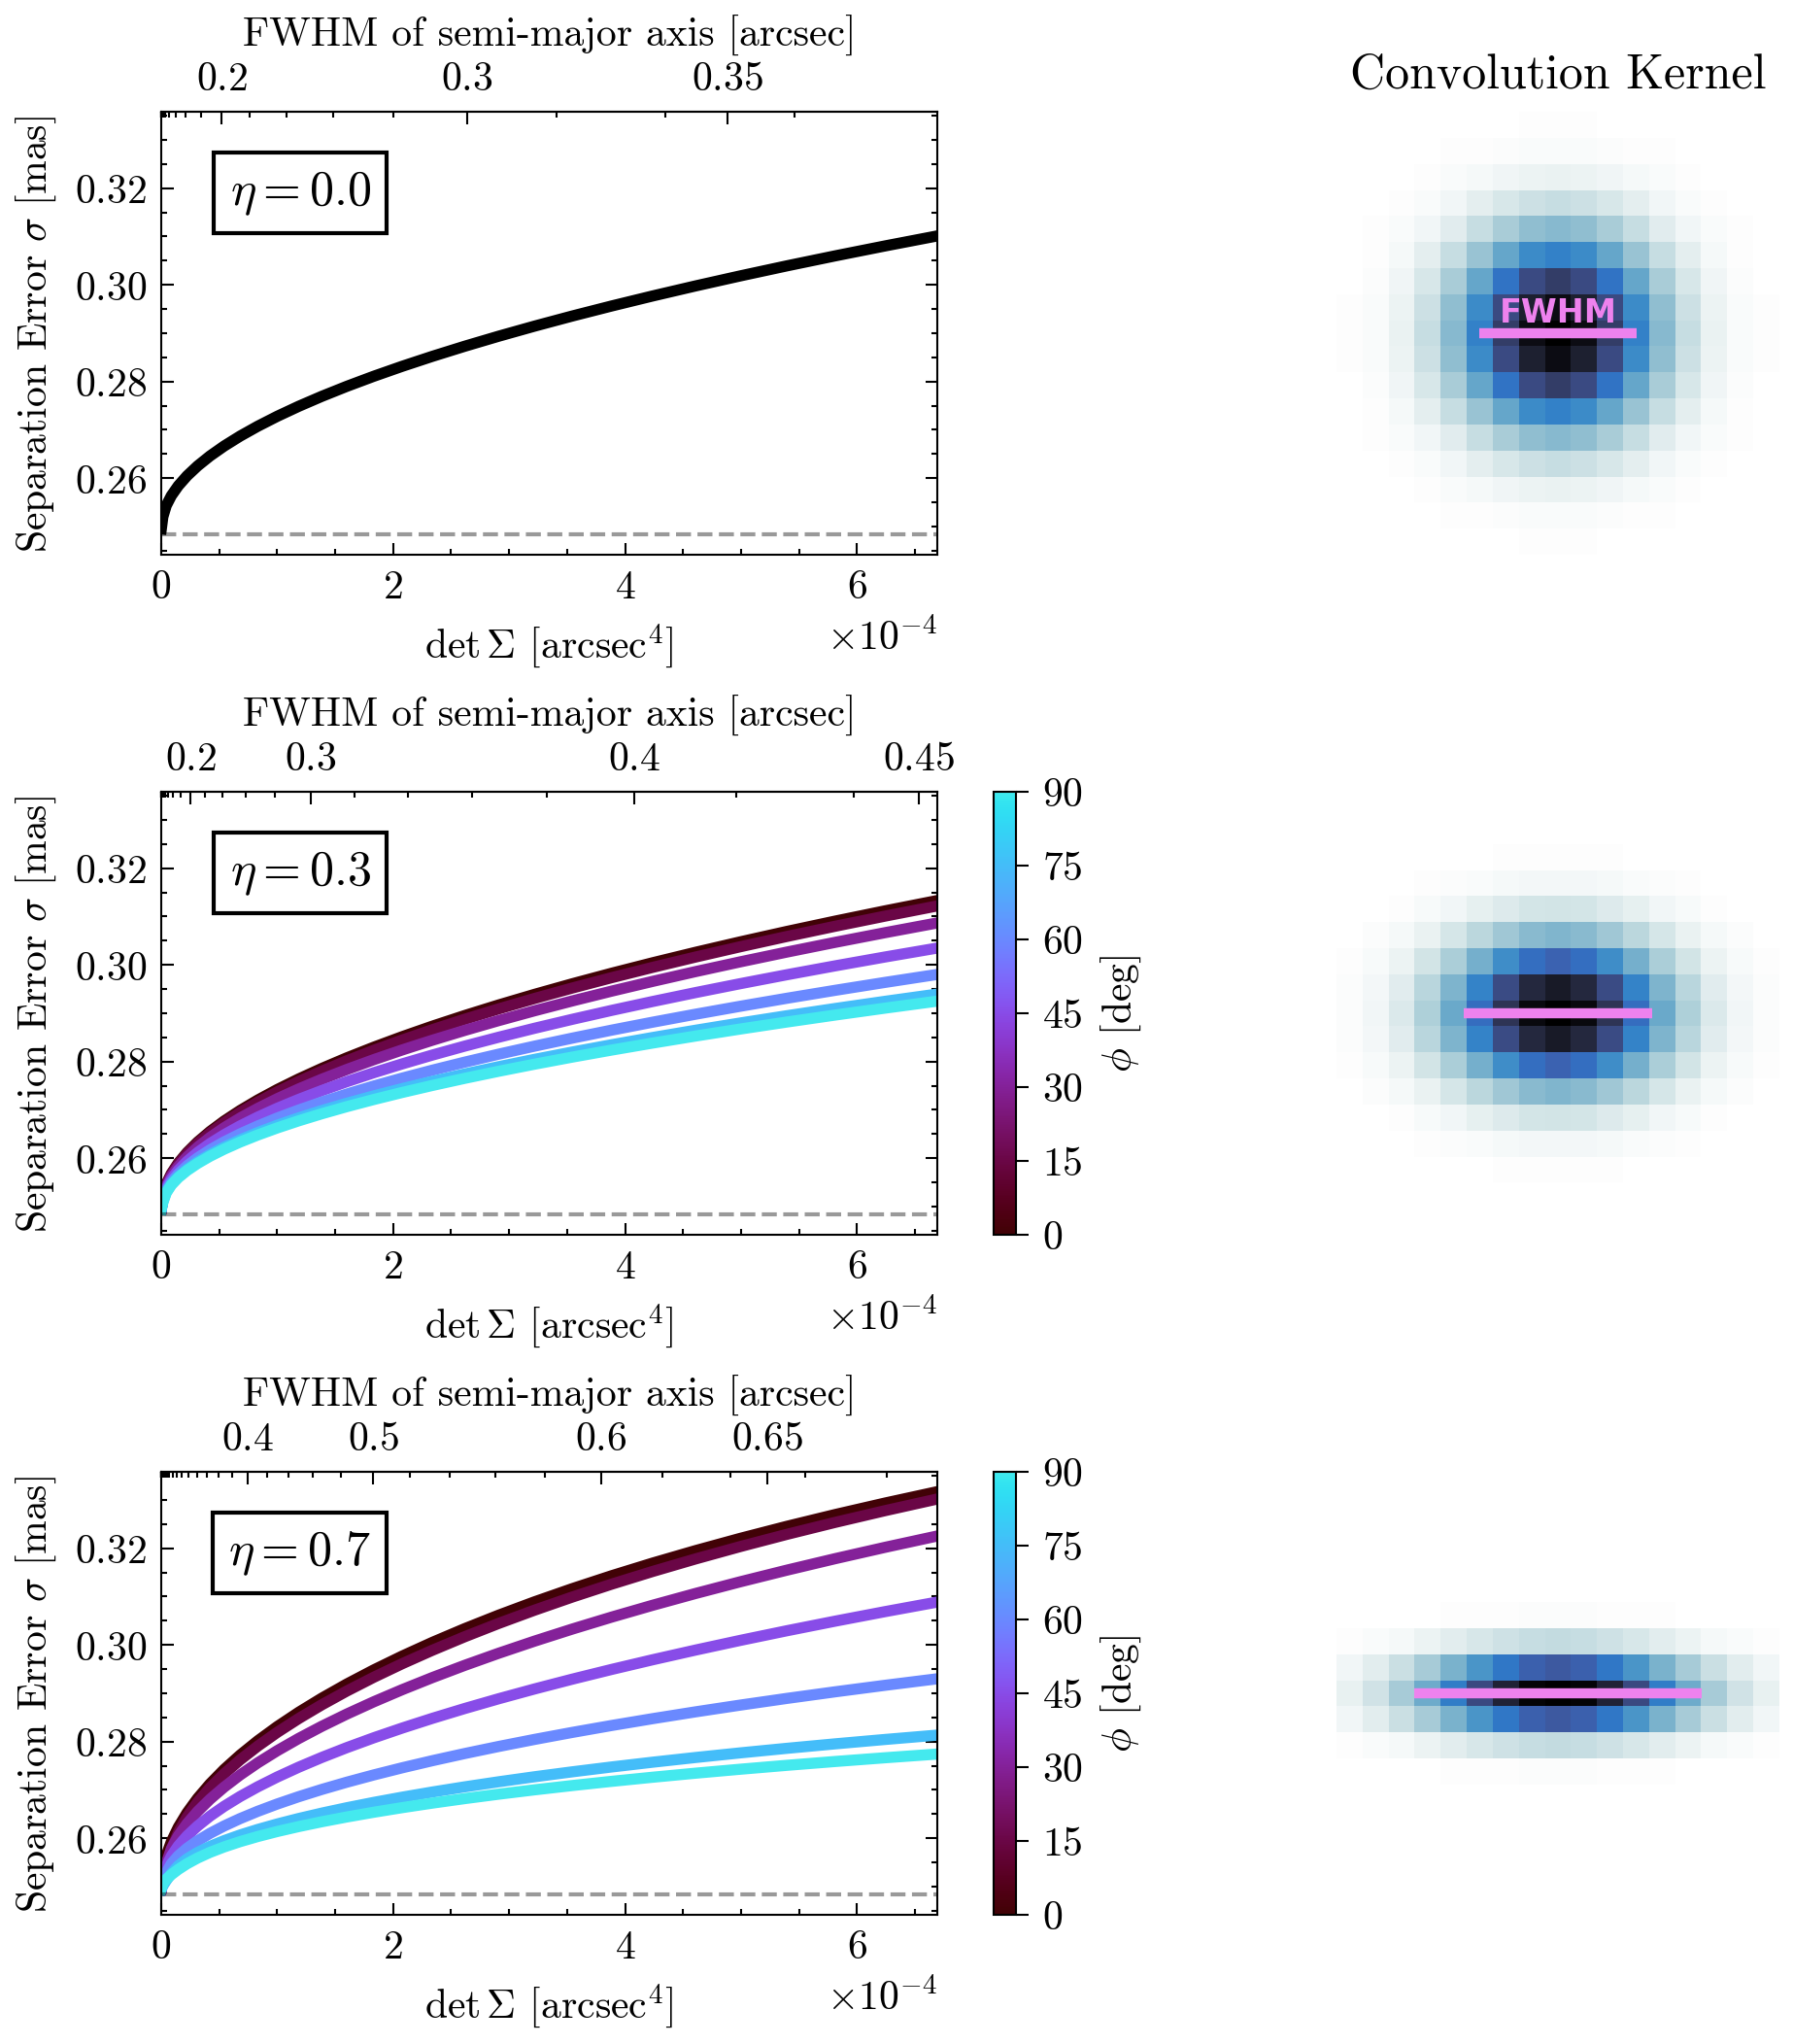

In [ ]:
# baseline = 0.24839681897145435  # previously calculated

cmap = mpl.colormaps["cmr.gem"]
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=0, vmax=90))
colors = cmap(phis / 90)

fig, axes = plt.subplots(
    len(shears), 2, figsize=(9, 7), sharey="col", layout="compressed"
)

for i, shear in enumerate(shears):
    ax, axe = axes[i]
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 2))
    ax.tick_params(axis="x", which="both", top=False)

    for sep, phi, c in zip(seps_norm[i].T, phis, colors):
        if shear == 0:
            label = None
            c = "k"
        else:
            label = label = r"$\phi\,=$" + f" {phi:.0f}"
        ax.plot(rs, 1000 * sep, label=label, color=c, marker=None, linewidth=2.75)
    ax.set(
        xlabel=r"det$\,\Sigma$ [arcsec$^{4}$]",
        ylabel=r"Separation Error $\sigma$ [mas]",
        # ylim=(baseline - 0.01, 0.8),
        xlim=(0, rs.max()),
    )

    ax.text(
        0.27,
        0.87,
        rf"$\eta={shear}$",
        size=12,
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox=dict(facecolor="white", edgecolor="black", boxstyle=None),
    )
    ax.axhline(
        baseline, linestyle="--", c="k", alpha=0.4, label="No Jitter", linewidth=1
    )

    if shear == 0:
        cbar = fig.colorbar(sm, ax=ax)
        cbar.ax.set_visible(False)  # Hide the colorbar visually
    else:
        cbar = fig.colorbar(sm, ax=ax, ticks=angs, label=r"$\phi$ [deg]")
        cbar.ax.minorticks_off()  # Ensure minor ticks are disabled
        cbar.ax.tick_params(direction="out")

    extent = (
        np.array([-kernel_size / 2, kernel_size / 2, -kernel_size / 2, kernel_size / 2])
        * det_pscale
        / oversample
    )
    c = axe.imshow(
        kernels[i],
        cmap="cmr.arctic_r",
        origin="lower",
        extent=extent,
    )
    axe.set(
        xticks=[],
        yticks=[],
    )
    axe.minorticks_off()

    max_fwhm = det_to_fwhm(rs.max(), shear)
    axe.hlines(
        0,
        -max_fwhm / 2,
        max_fwhm / 2,
        colors="violet",
        linestyles="solid",
        label="FWHM",
        linewidth=2.5,
    )

    for spine in ["top", "right", "left", "bottom"]:
        axe.spines[spine].set_visible(False)

    if shear == 0:
        axe.set_title("Convolution Kernel")
        axe.text(
            0.0,
            0.05,
            "FWHM",
            size=8,
            ha="center",
            va="center",
            c="violet",
            weight="bold",
            fontname="Georgia",
        )


# SECONDARY AXES (was buggy so had to remove from loop)

# First subplot
ax00 = axes[0][0].secondary_xaxis(
    "top",
    functions=(
        lambda r: det_to_fwhm(r, shears[0]),
        lambda fwhm: fwhm_to_det(fwhm, shears[0]),
    ),
)
ax00.set_xticks([0.2, 0.3, 0.35])  # Custom major xticks
ax00.set_xticklabels([r"$0.2$", r"$0.3$", r"$0.35$"])  # Custom labels for major ticks
ax00.minorticks_on()  # Enable minor ticks
ax00.xaxis.set_minor_locator(
    mpl.ticker.AutoMinorLocator(5)
)  # 5 minor ticks between major ticks
ax00.set_xlabel("FWHM of semi-major axis [arcsec]")

# Second subplot
ax11 = axes[1][0].secondary_xaxis(
    "top",
    functions=(
        lambda r: det_to_fwhm(r, shears[1]),
        lambda fwhm: fwhm_to_det(fwhm, shears[1]),
    ),
)
ax11.set_xticks([0.2, 0.3, 0.4, 0.45])  # Custom major xticks
ax11.set_xticklabels(
    [r"$0.2$", r"$0.3$", r"$0.4$", r"$0.45$"]
)  # Custom labels for major ticks
ax11.minorticks_on()  # Enable minor ticks
ax11.xaxis.set_minor_locator(
    mpl.ticker.AutoMinorLocator(5)
)  # 5 minor ticks between major ticks
ax11.set_xlabel("FWHM of semi-major axis [arcsec]")

# First subplot
ax22 = axes[2][0].secondary_xaxis(
    "top",
    functions=(
        lambda r: det_to_fwhm(r, shears[2]),
        lambda fwhm: fwhm_to_det(fwhm, shears[2]),
    ),
)
ax22.set_xticks([0.4, 0.5, 0.6, 0.65])  # Custom major xticks
ax22.set_xticklabels(
    [r"$0.4$", r"$0.5$", r"$0.6$", r"$0.65$"]
)  # Custom labels for major ticks
ax22.minorticks_on()  # Enable minor ticks
ax22.xaxis.set_minor_locator(
    mpl.ticker.AutoMinorLocator(5)
)  # 5 minor ticks between major ticks
ax22.set_xlabel("FWHM of semi-major axis [arcsec]")

plt.savefig("files/paper_figs/norm_sweep.pdf", bbox_inches="tight", dpi=500)
plt.show()

## Model Cross-Fitting

The code for model cross-fitting to investigate systematic model-introduced bias and a potential increase in separation error.

In [8]:
from matplotlib import colormaps, colors


def plot_losses(losses, start, stop=-1):
    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 1)
    plt.title("Full Loss")
    plt.plot(losses)

    if start >= len(losses):
        start = 0
    last_losses = losses[start:stop]
    n = len(last_losses)
    plt.subplot(1, 2, 2)
    plt.title(f"Final {n} Losses")
    plt.plot(np.arange(start, start + n), last_losses)

    plt.tight_layout()
    plt.show()


def summarise_fit(
    model,
    data,
    loglike_fn,
):

    inferno = colormaps["inferno"]
    seismic = colormaps["seismic"]
    inferno.set_bad("k", 0.5)
    seismic.set_bad("k", 0.5)

    sim = model.model()
    residual = data - sim

    loglike_im = loglike_fn(model, data)
    final_loss = np.nanmean(-loglike_im)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title(f"Pixel neg log posterior: {final_loss:,.1f}")
    plt.imshow(-loglike_im, cmap="viridis")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("Mean noise normalised slope residual")
    plt.imshow(residual, cmap=seismic, norm=colors.CenteredNorm())
    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [9]:
def run_grad_desc(
    model,
    data,
    optimisers: dict,
    loglike_fn,
    norm_fn=lambda model: model,
    iters=100,
    plot=False,
    verbose=True,
    eps=None,  # termination condition
):
    """
    Run gradient descent on a model.
    """

    # run gradient descent
    params = list(optimisers.keys())
    optim, opt_state = zdx.get_optimiser(model, params, list(optimisers.values()))
    losses, models_out = [], []

    @zdx.filter_jit
    @zdx.filter_value_and_grad(list(optimisers.keys()))
    def loss_func(model, data):
        return -loglike_fn(model, data).sum()

    if verbose:
        t = tqdm(range(iters), desc="Gradient Descent")
    else:
        t = range(iters)

    for i in t:

        # for termination condition
        last_params = model.get(params)

        loss, grads = loss_func(model, np.round(data))

        # print(grads)

        updates, opt_state = optim.update(grads, opt_state)
        model = zdx.apply_updates(model, updates)
        model = norm_fn(model)

        models_out.append(model)
        losses.append(loss)

        if verbose:
            t.set_description("Loss: {:.6e}".format(loss))  # update the progress bar

        # Termination condition
        new_params = model.get(params)  # getting new parameters
        scaled_diffs = jax.tree.map(
            lambda x, y: np.abs((x - y) / y),
            last_params,
            new_params,
        )
        if eps is not None and i > 5:
            if np.all(
                np.array(  # if all parameters have converged
                    jax.tree.map(lambda x: np.all(x < eps), scaled_diffs)
                )
            ):
                print("Converged early")
                break

    if plot:
        plot_losses(losses, 10)
        summarise_fit(model, data, loglike_fn)

        params_in = params
        for p in np.arange(0, len(params), 2):
            plt.figure(figsize=(10, 3))
            plt.subplot(1, 2, 1)

            param = params_in[p]
            param_out = np.array([m.get(param) for m in models_out])

            if param_out.size // iters > 1:
                plt.plot(range(i + 1), param_out - param_out[0], label=param)
            else:
                plt.plot(range(i + 1), param_out, label=param)
            plt.xlabel("Epoch")
            plt.legend()
            plt.ticklabel_format(style="plain", axis="both", useOffset=False)

            plt.subplot(1, 2, 2)
            if p + 1 == len(params_in):
                plt.tight_layout()
                plt.show()
                break

            param = params_in[p + 1]
            param_out = np.array([m.get(param) for m in models_out])

            if param_out.size // iters > 1:
                plt.plot(range(i + 1), param_out - param_out[0], label=param)
            else:
                plt.plot(range(i + 1), param_out, label=param)

            plt.xlabel("Epoch")
            plt.legend()
            plt.ticklabel_format(style="plain", axis="both", useOffset=False)

            plt.tight_layout()
            plt.show()

    return models_out[-1]

In [36]:
from zodiax.optimisation import sgd, adam

sep_dict_save_dir = "files/sep_dicts/"

if run_compute:
    sep_dict = {}
    n_realisations = 500

    # Gradient descent
    common_optimisers = {
        "separation": sgd(1e-8, 0),
        "position_angle": sgd(3e-7, 3),
        "x_position": sgd(3e-9, 0),
        "y_position": sgd(3e-9, 2),
        "log_flux": sgd(2e-9, 0),
        "contrast": sgd(1e-6, 1),
        "aperture.coefficients": sgd(2e-4, 0),
    }

    lin_opts = {
        "jitter_mag": sgd(2e-7, 0),
        "jitter_angle": sgd(5e-2, 0),
    }

    norm_opts = {
        # "Jitter.r": sgd(2e-2, 15),
        "Jitter.r": sgd(1e-3, 15),
        "Jitter.shear": sgd(1e-5, 0),
        "Jitter.phi": sgd(5e-1, 0),
    }

    # # looping over models
    # for model_key in tqdm(models.keys(), desc="Models"):

    #     if model_key == "norm":
    #         optimisers = {**common_optimisers, **norm_opts}
    #     else:
    #         optimisers = {**common_optimisers, **lin_opts}

    #     model = models[model_key]
    #     loglike_fn = loglike_fns[model_key]

    #     @zdx.filter_jit
    #     @zdx.filter_value_and_grad(list(optimisers.keys()))
    #     def loss_func(model, data):
    #         return -loglike_fn(model, data)

    #     # looping over data arrays
    #     for data_key in tqdm(datas.keys(), desc="Data Arrays"):
    #         data = datas[data_key]
    #         sep_values = np.array([], dtype=np.float64)

    #         if model_key == "norm":
    #             continue

    #         # looping over noise realisations
    #         for i in tqdm(range(n_realisations), desc="Noise Realisations"):

    #             noisy_data = jr.poisson(
    #                 jr.PRNGKey(random.randint(0, int(1e8))),
    #                 data,
    #             )

    #             # RUN GRAD DESCENT
    #             gd_model = run_grad_desc(
    #                 model,
    #                 noisy_data,
    #                 list(optimisers.keys()),
    #                 optimisers=list(optimisers.values()),
    #                 iters=100,
    #                 loss_func=loss_func,
    #                 eps=1e-5,
    #                 plot=False,
    #             )

    #             sep_values = np.append(sep_values, gd_model.separation)
    #         sep_dict[f"{model_key}_{data_key}"] = sep_values

    # # saving
    # current_time = datetime.now().strftime("%d-%m-%Y_%H-%M")
    # save_str = current_time + f"_{n_realisations:04d}.npy"
    # np.save(os.path.join(sep_dict_save_dir, save_str), sep_dict)

Gradient Descent:   0%|          | 0/250 [00:00<?, ?it/s]

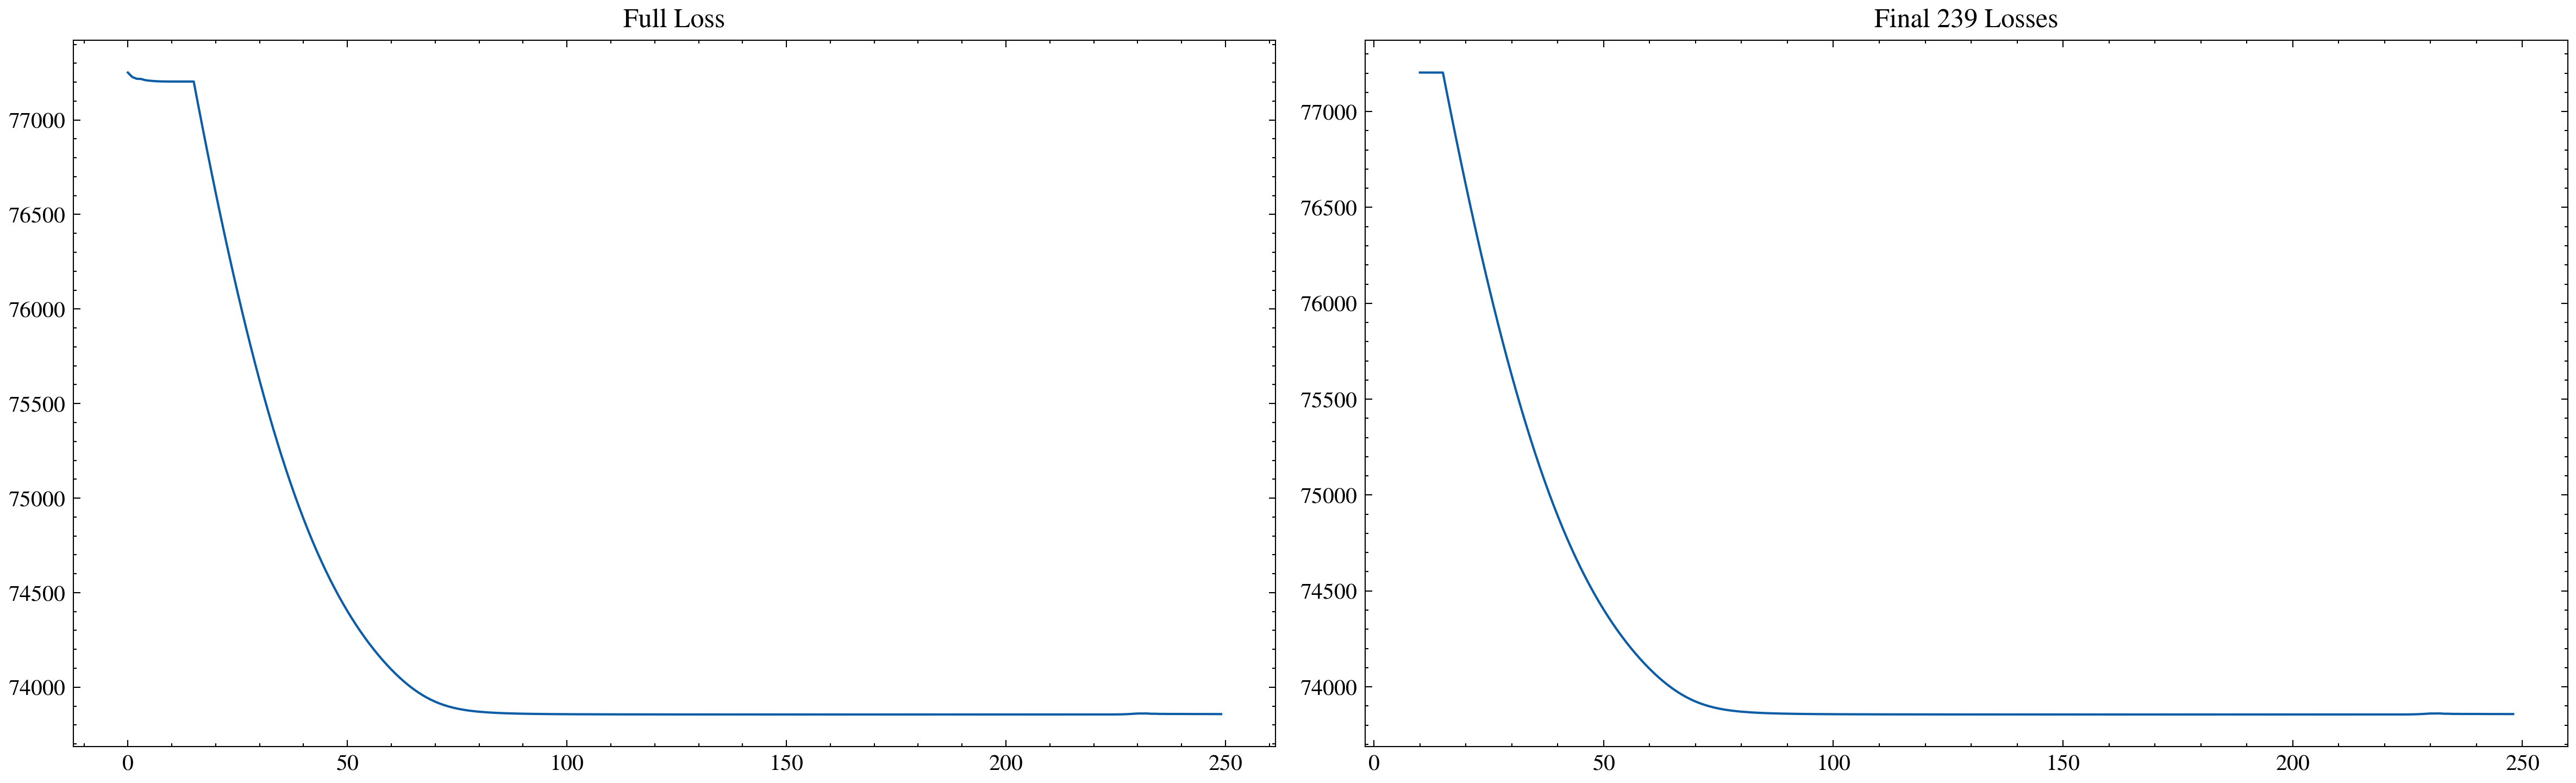

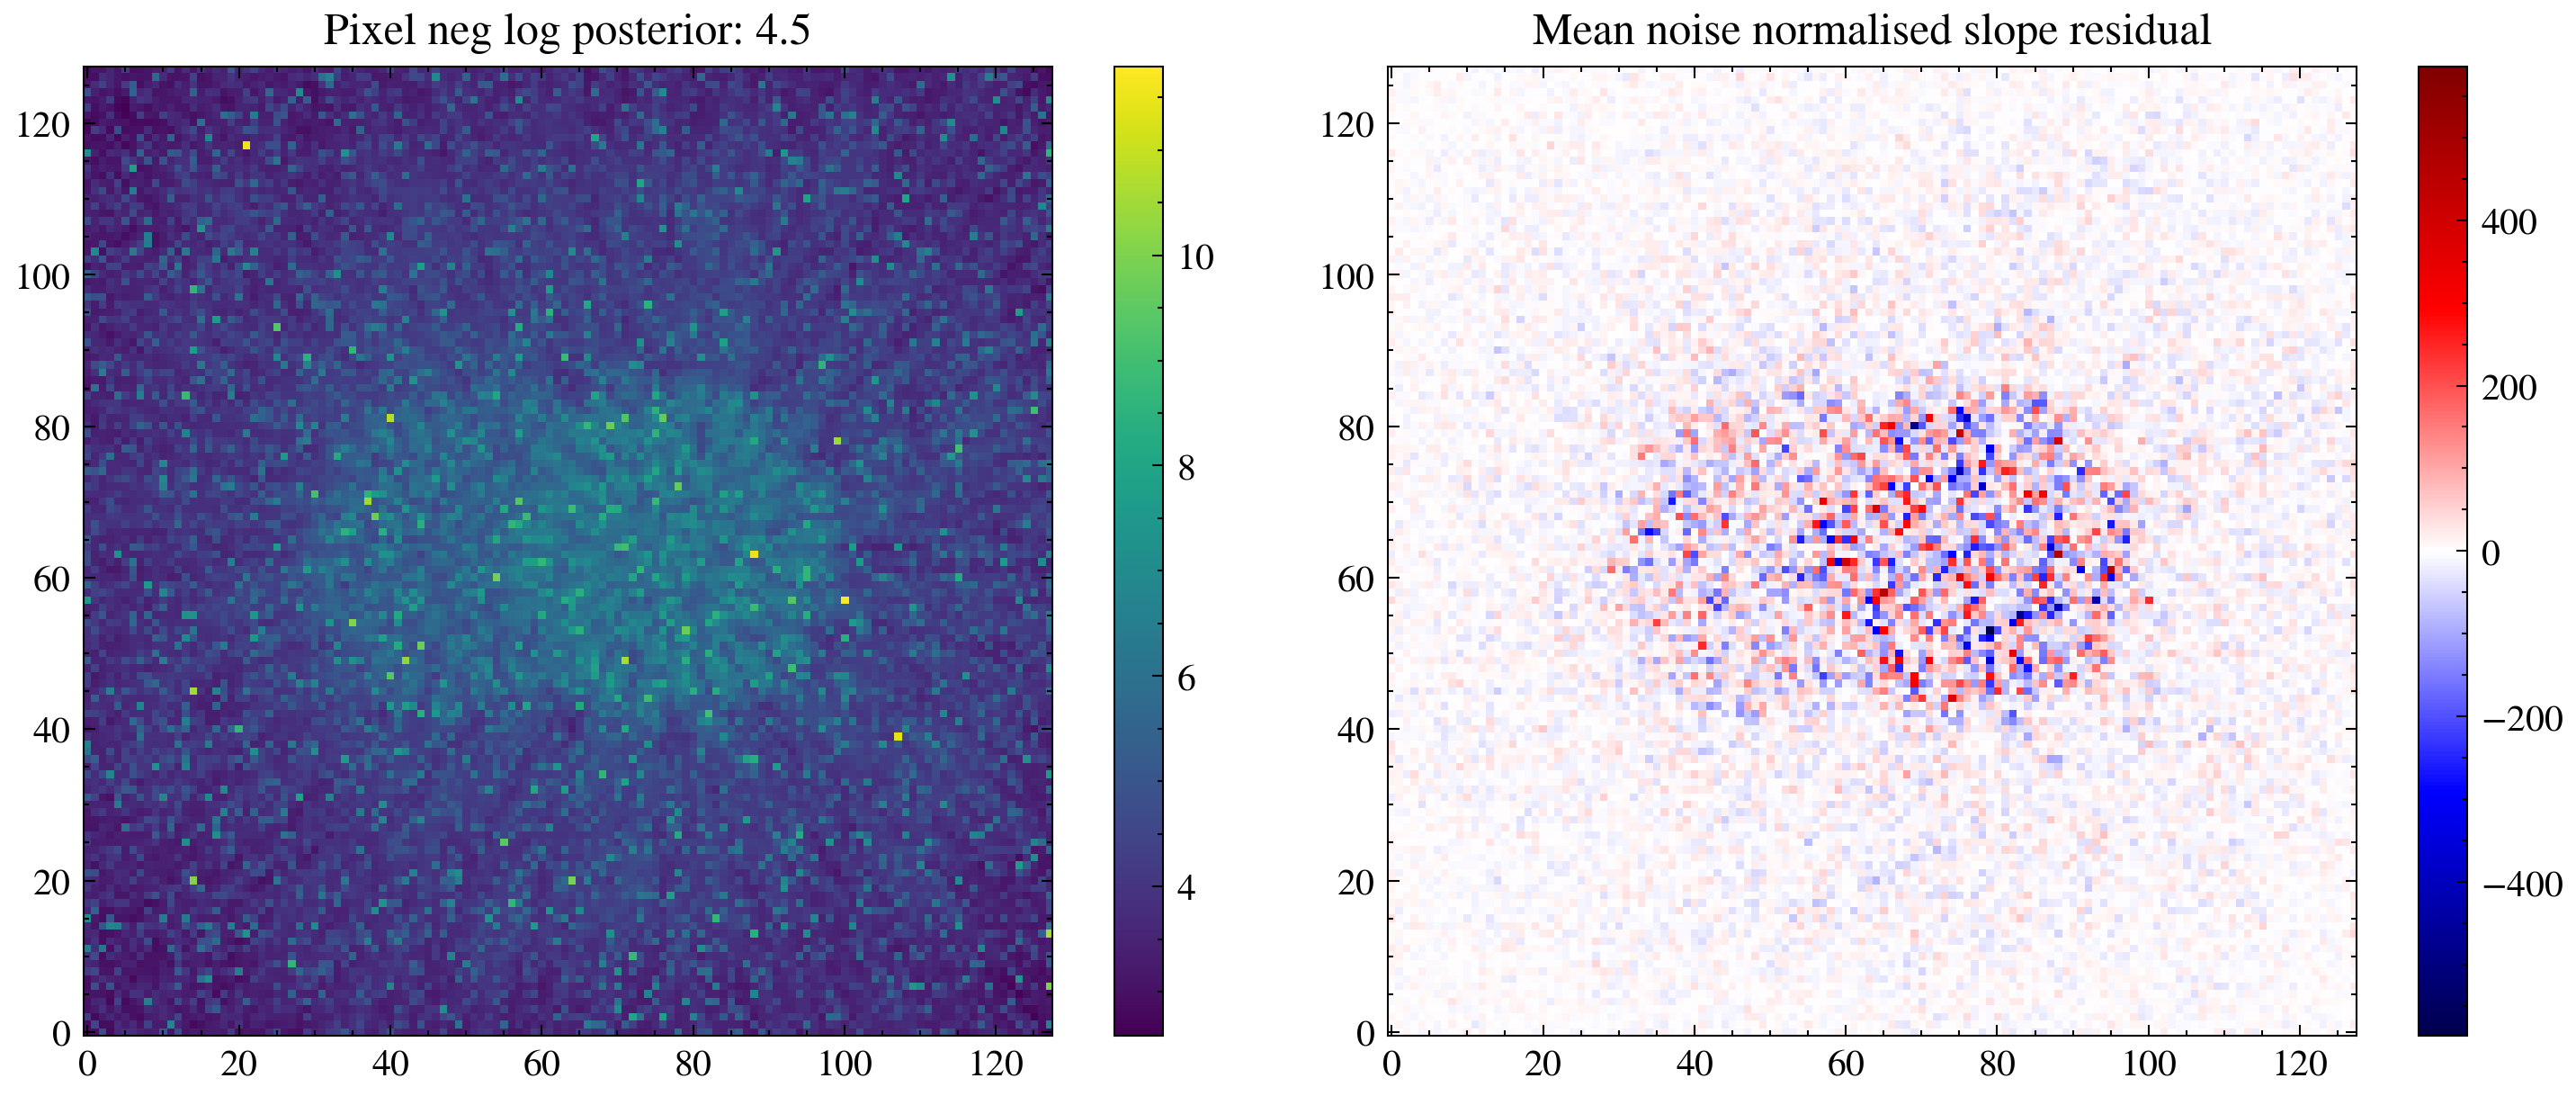

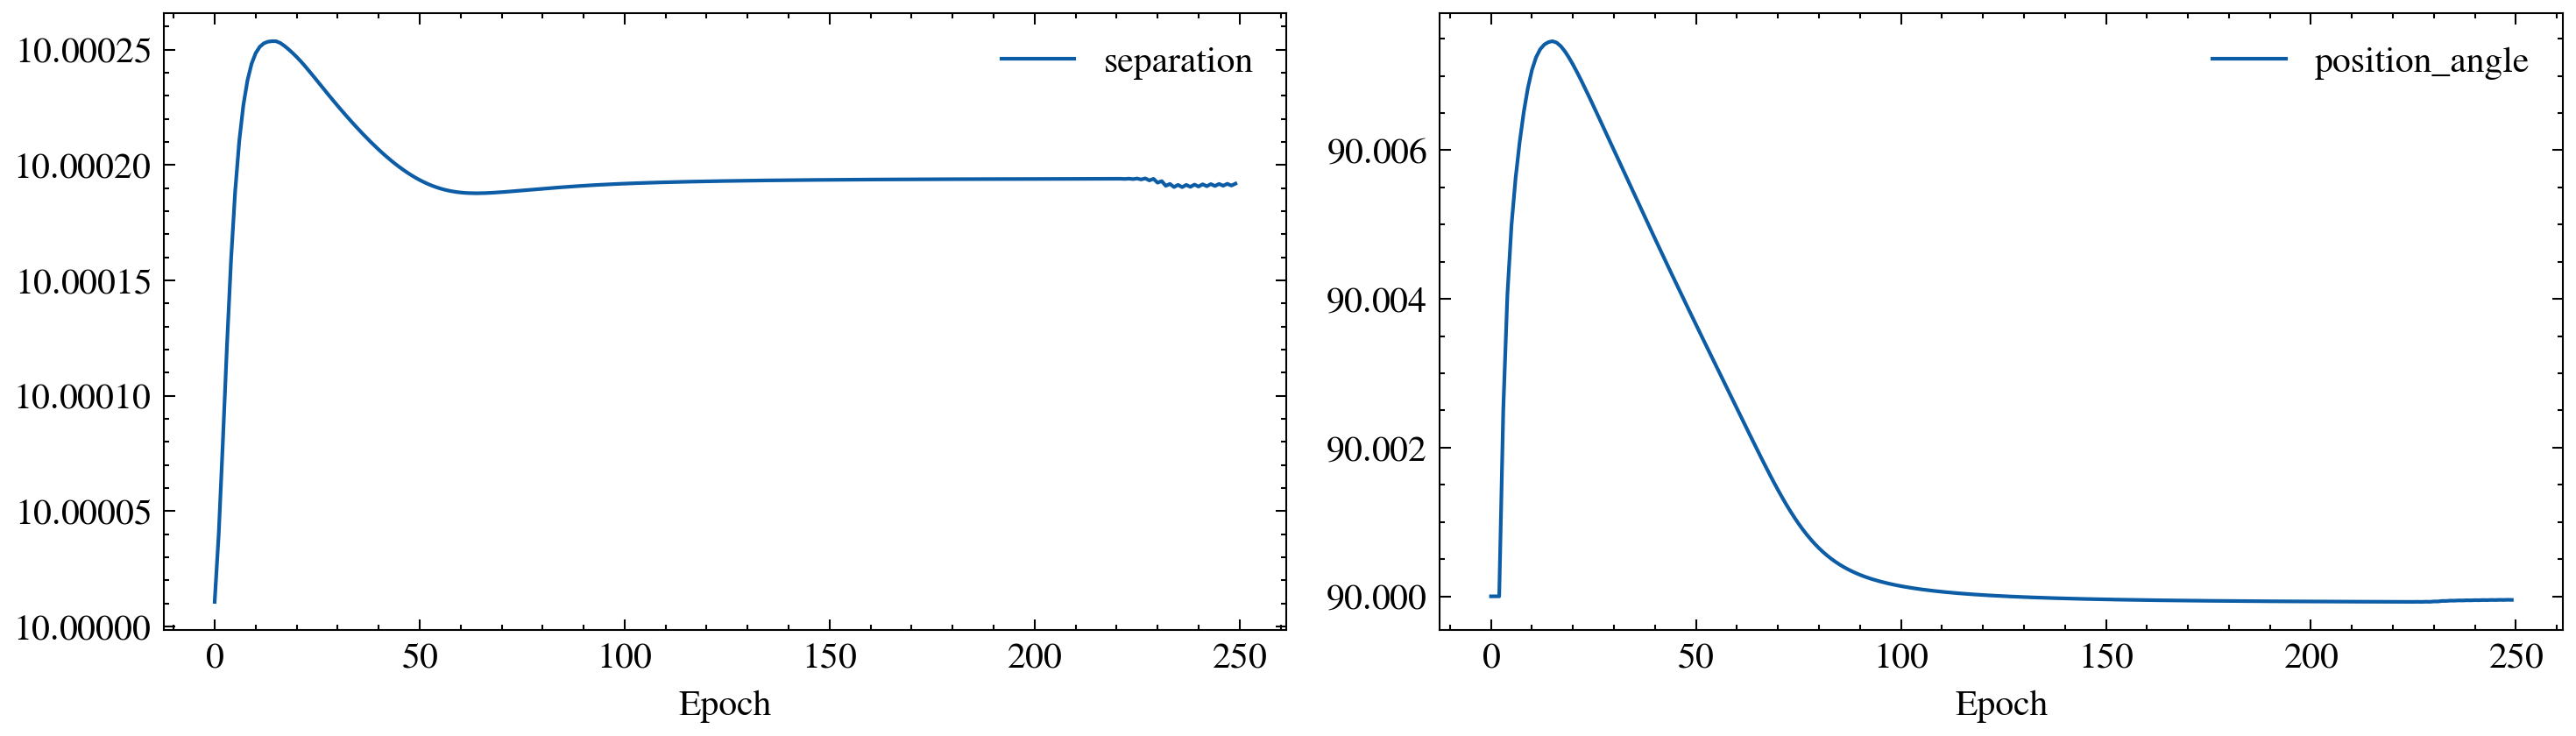

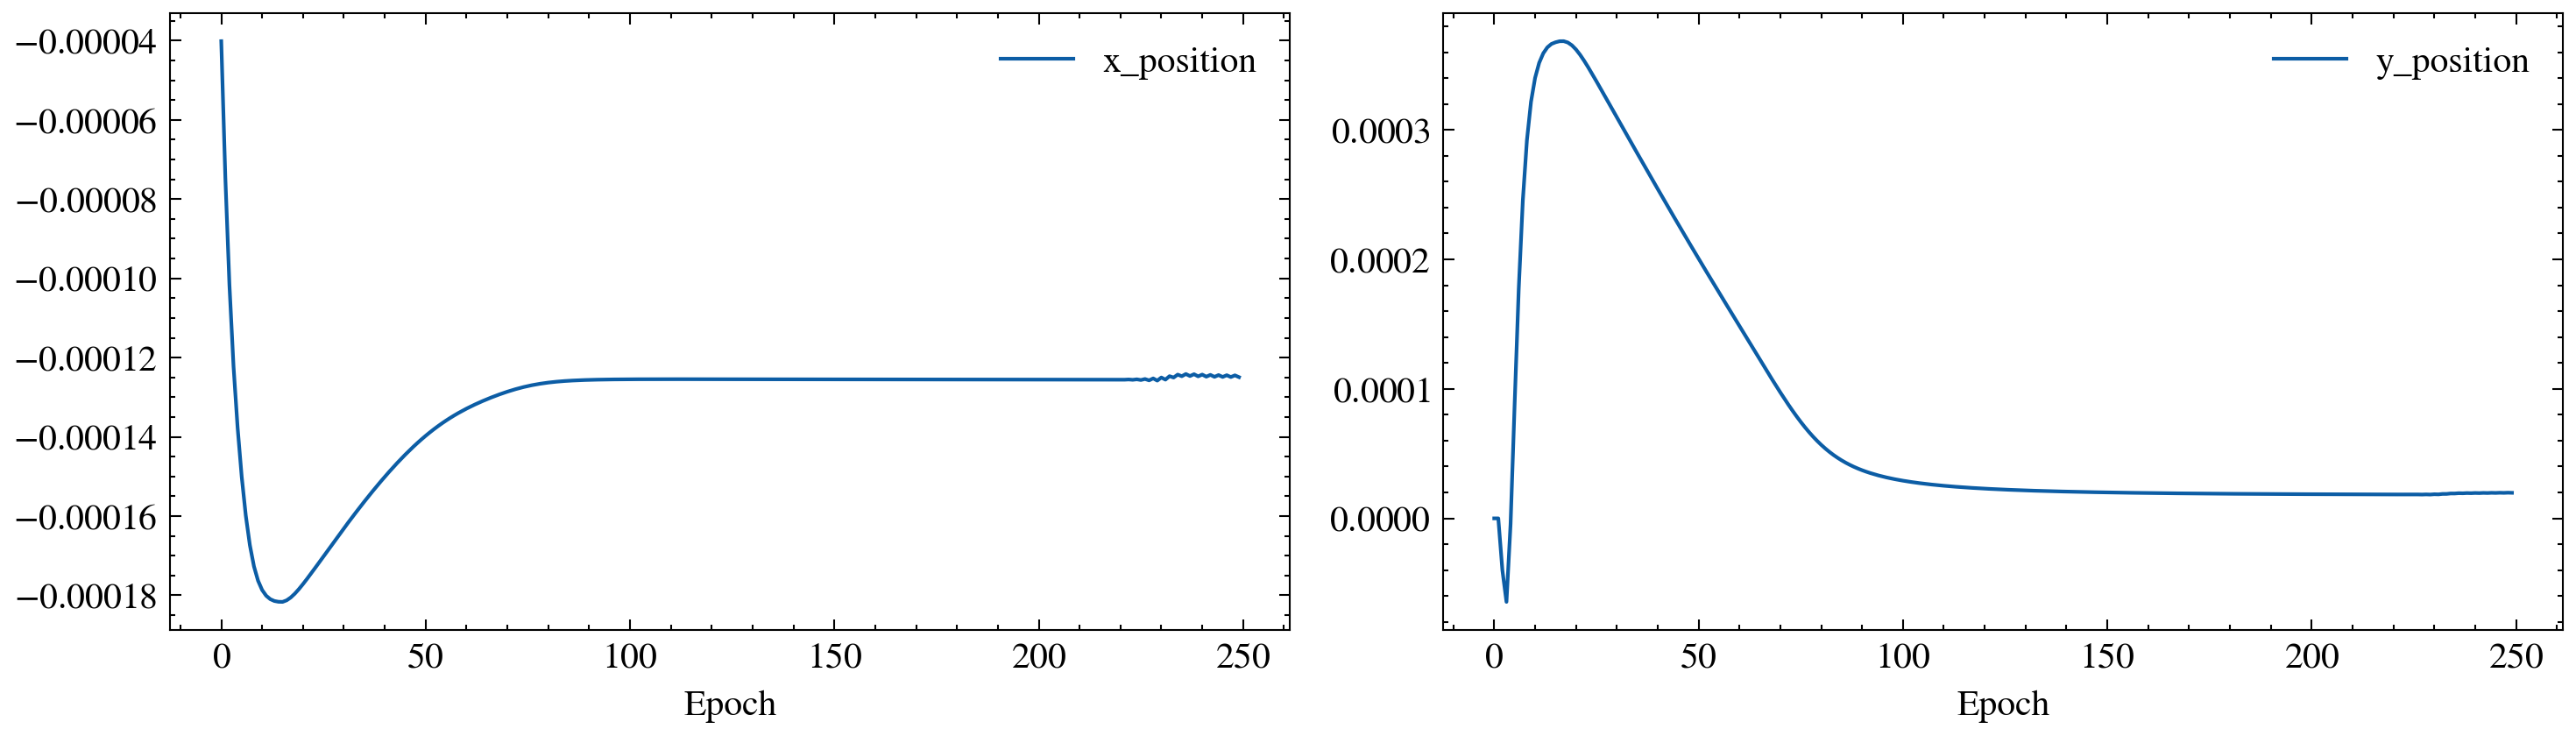

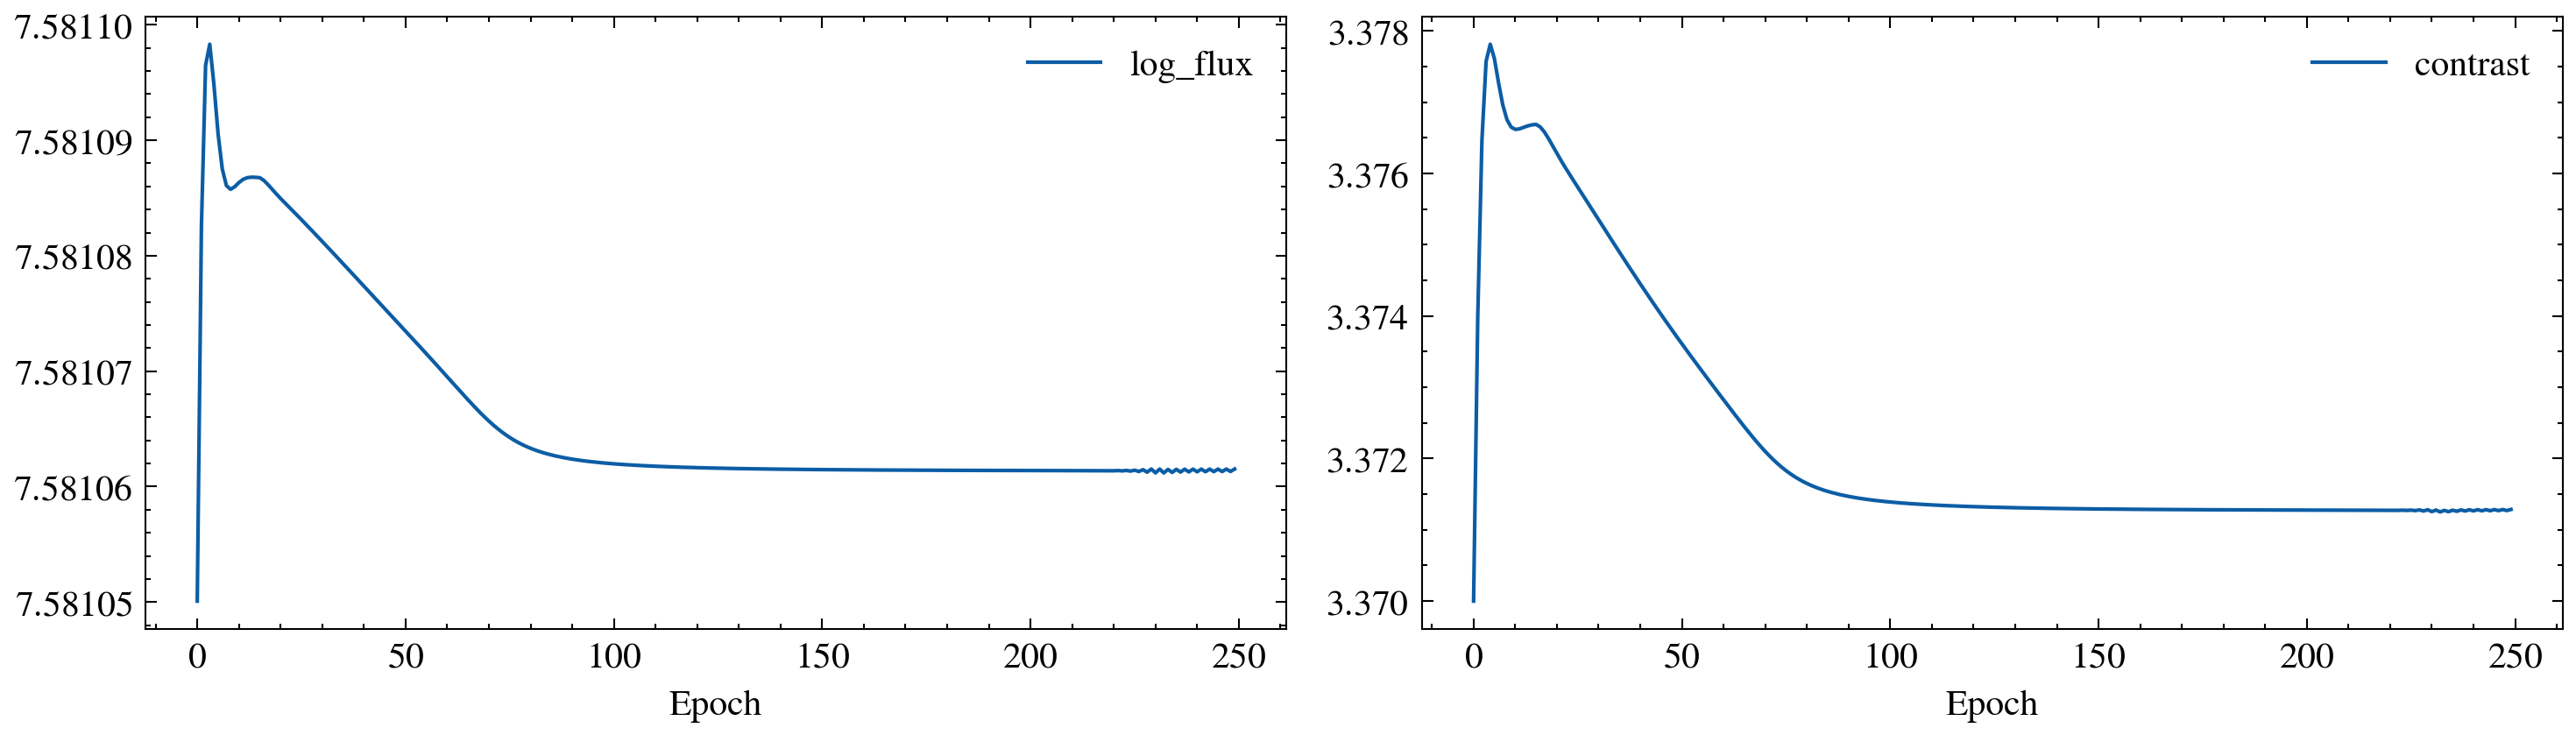

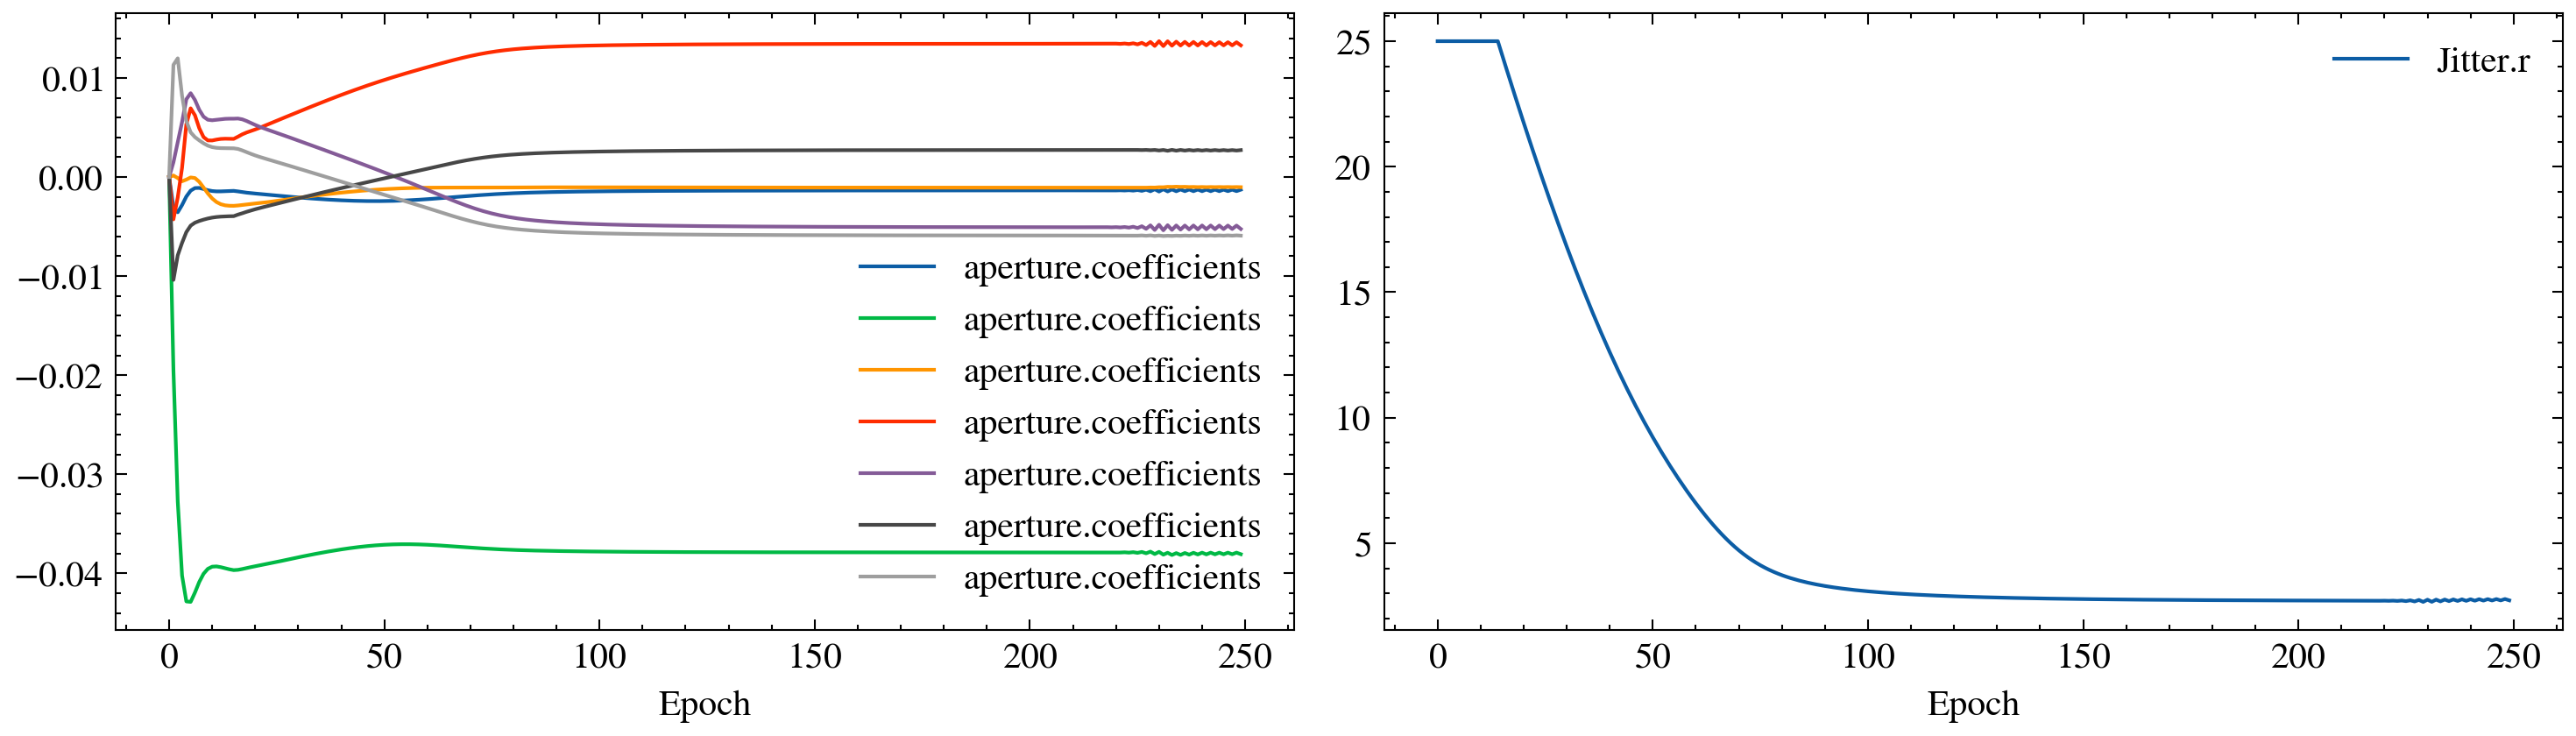

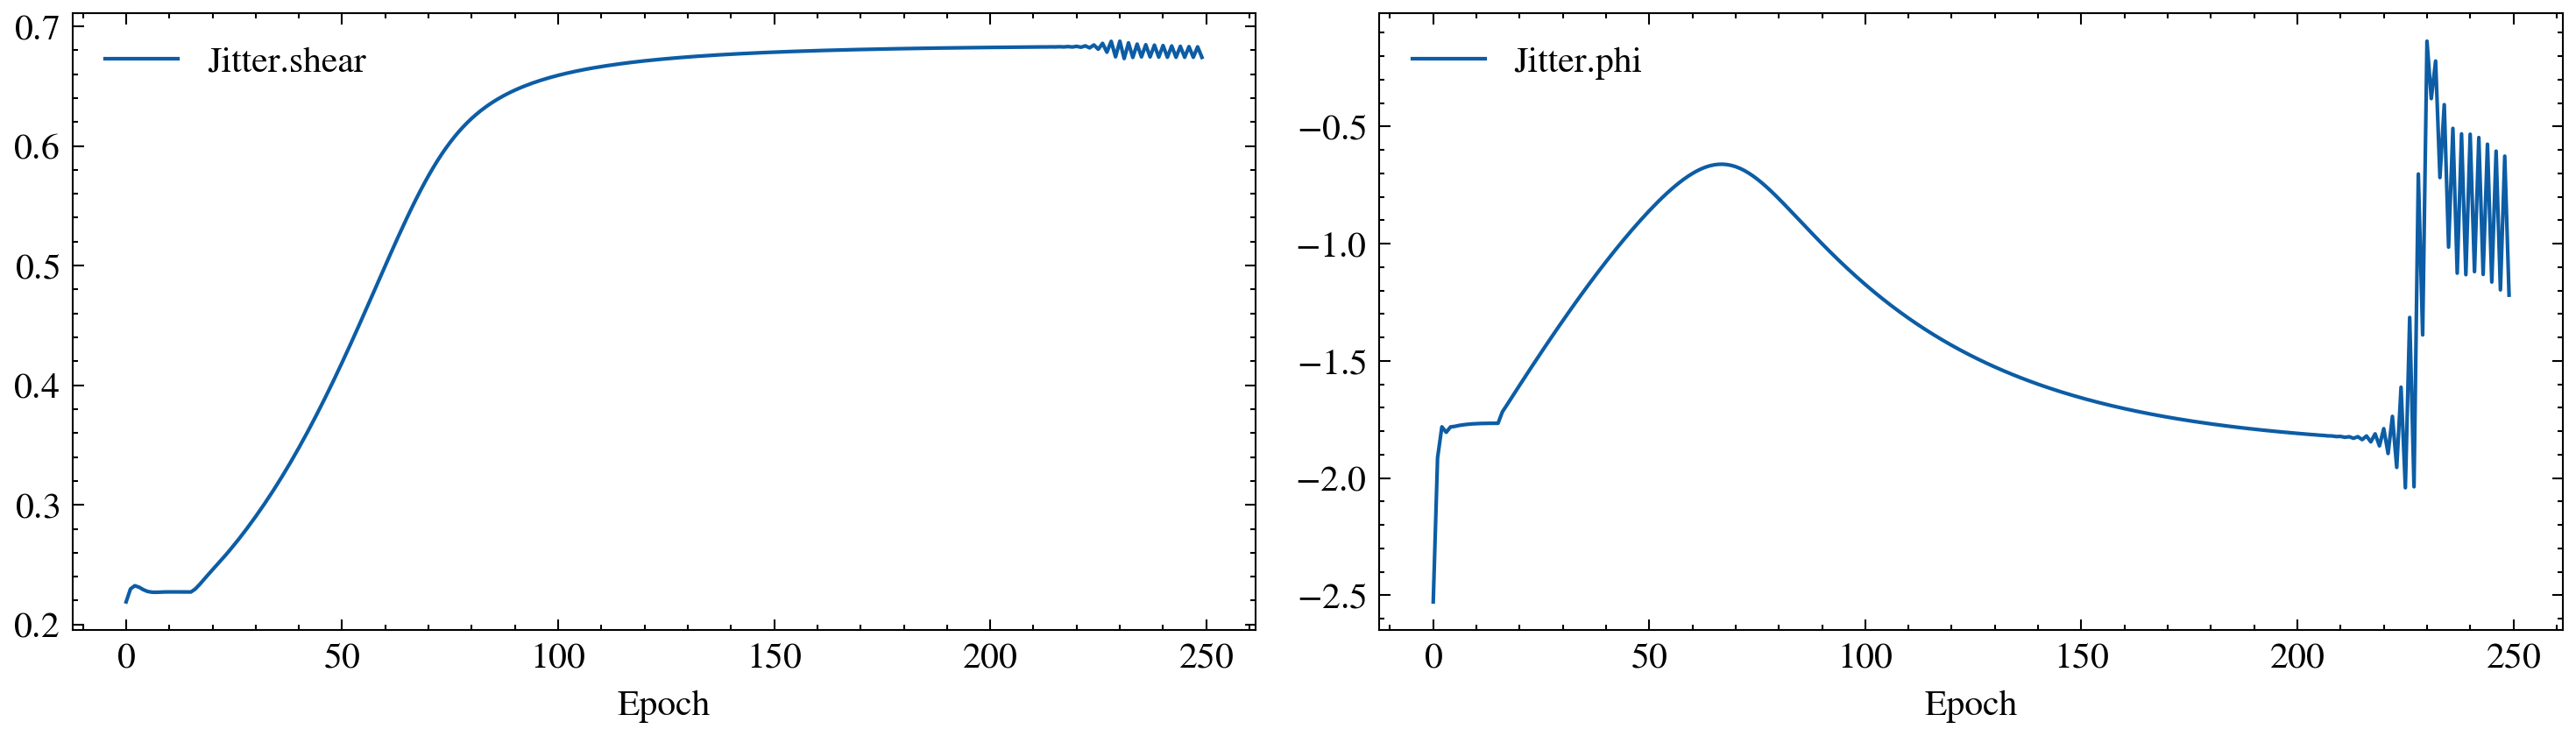

In [37]:
model = models["norm"]
data = datas["lin"]
# data = datas["norm"]
loglike_fn = loglike_fns["norm"]
optimisers = {**common_optimisers, **norm_opts}

noisy_data = jr.poisson(jr.PRNGKey(random.randint(0, int(1e8))), data)


def normalisation_fn(model):
    # return model.set("Jitter.r", np.array(1e-16))
    return model.set("Jitter.r", np.clip(model.Jitter.r, 1e-16))


gd_model = run_grad_desc(
    model,
    noisy_data,
    optimisers=optimisers,
    loglike_fn=loglike_fn,
    norm_fn=normalisation_fn,
    iters=250,
    eps=1e-5,
    plot=True,
)

In [38]:
total_sep_dict = {}
sep_dict_save_dir = "files/sep_dicts/"

# looping over saved sep_dicts
for f in os.listdir(sep_dict_save_dir):
    if not f.endswith(".npy"):
        continue

    # loading each file
    this_dict = np.load(os.path.join(sep_dict_save_dir, f), allow_pickle=True).item()

    # appending to total_sep_dict
    for k in this_dict.keys():
        total_sep_dict[k] = (
            np.append(total_sep_dict[k], this_dict[k])
            if k in total_sep_dict.keys()
            else this_dict[k]
        )

In [39]:
import numpy as onp


def bootstrap_histogram(histogram: Array, num_bootstraps: int) -> Array:
    """
    Perform bootstrapping on a histogram to get theuncertainty in the mean and standard deviation.
    """
    boot_means = []
    boot_stds = []

    for _ in range(num_bootstraps):
        resampled_data = onp.random.choice(
            histogram,
            size=len(histogram),
            replace=True,
        )
        boot_means.append(np.mean(resampled_data))
        boot_stds.append(np.std(resampled_data, ddof=1))

    # Compute statistics
    mean_estimate = np.mean(histogram)
    std_estimate = np.std(histogram)
    mean_uncertainty = np.std(np.array(boot_means))
    std_uncertainty = np.std(np.array(boot_stds))

    return mean_estimate, mean_uncertainty, std_estimate, std_uncertainty

3000 noise realisations.


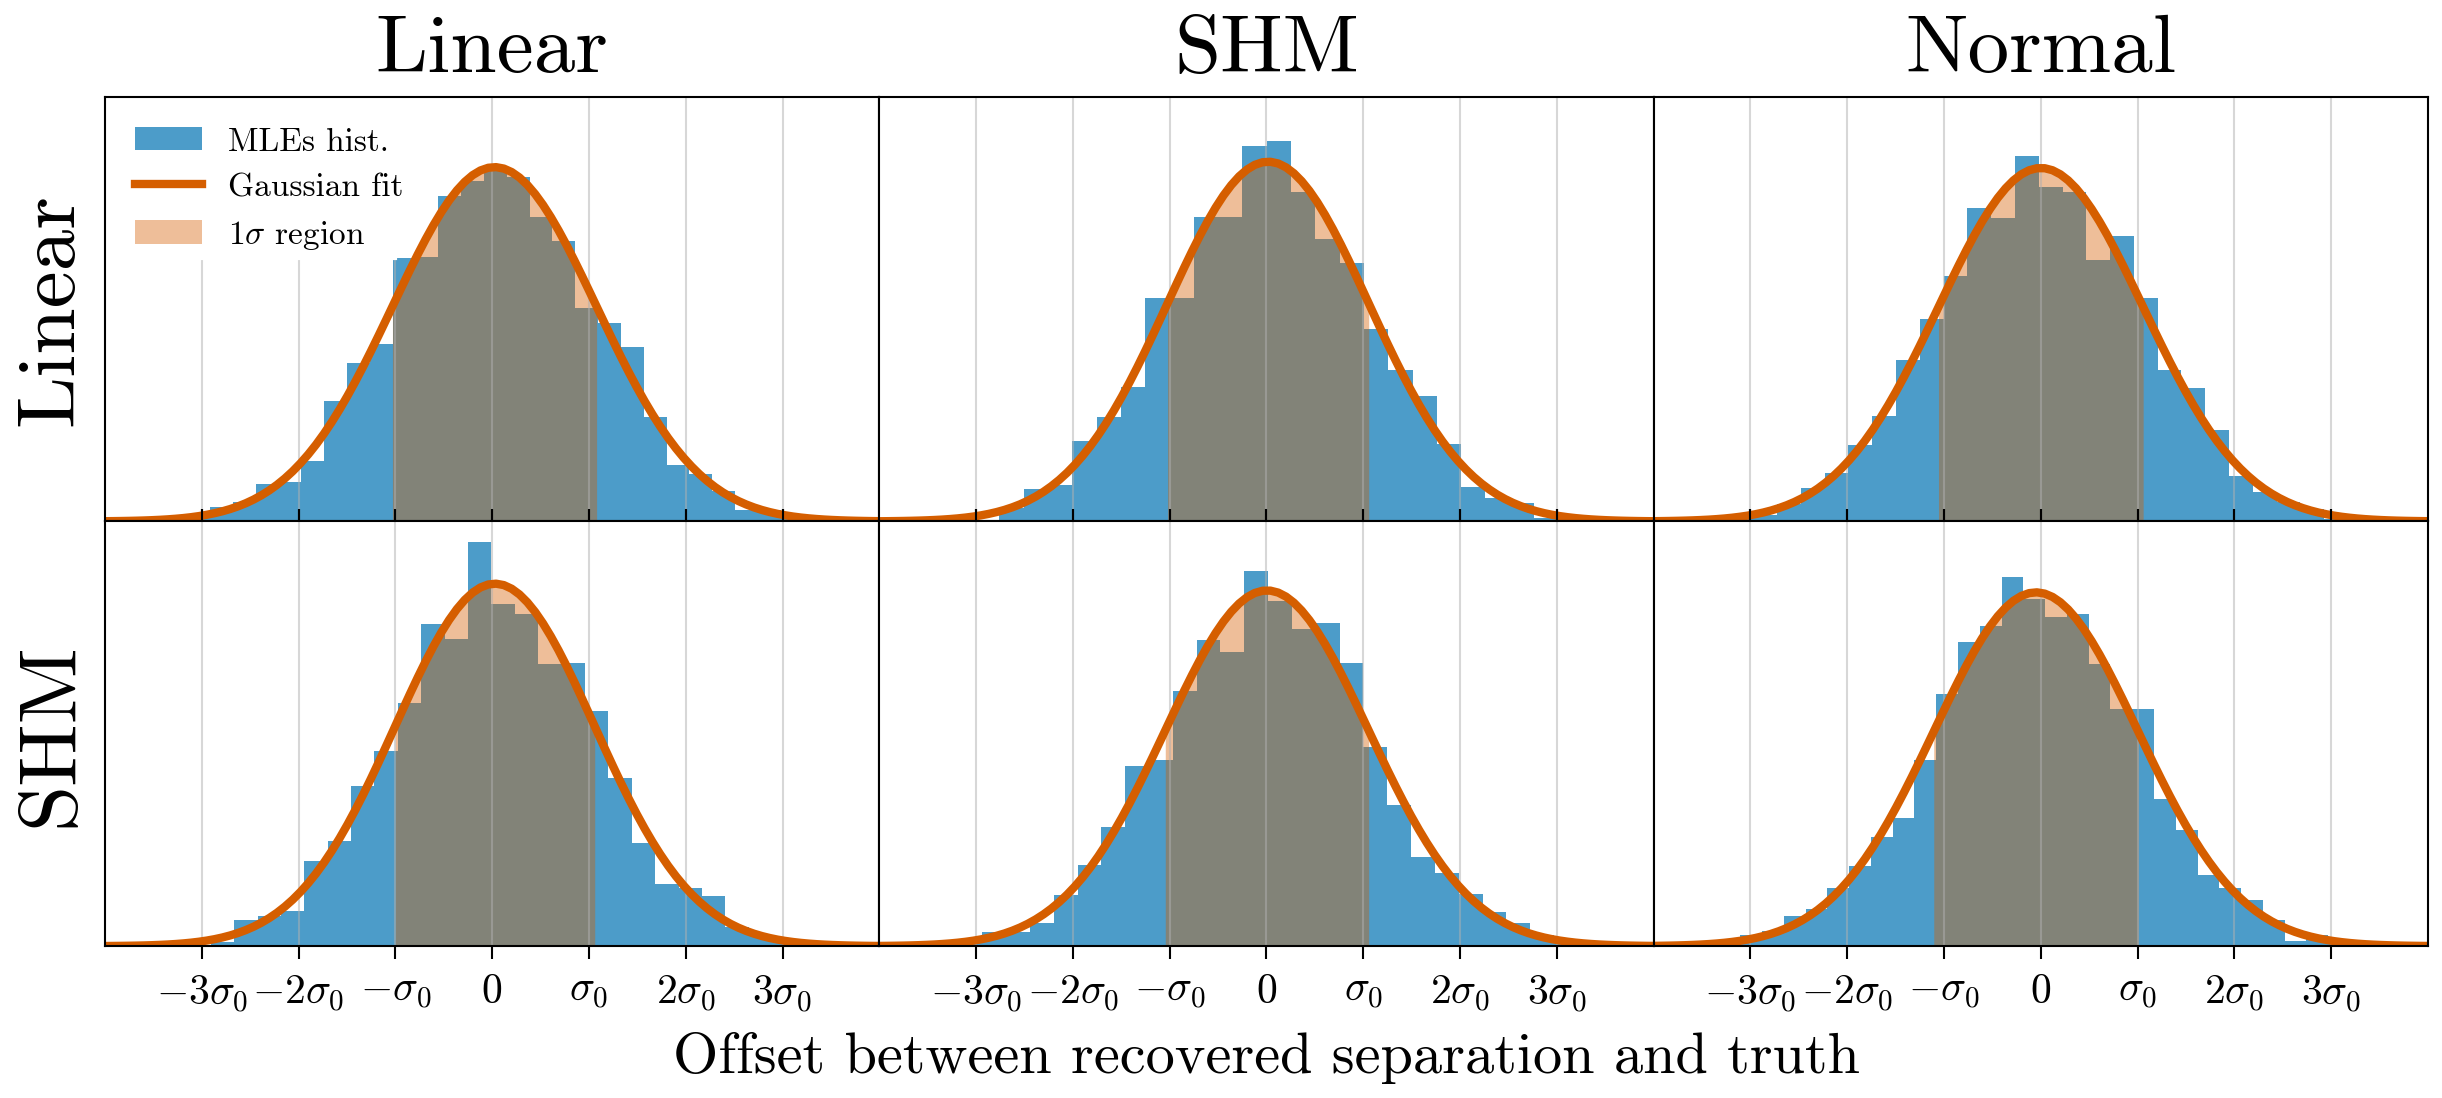

In [21]:
print(f"{len(list(total_sep_dict.values())[0])} noise realisations.")

n_bins = 30
true_sep = models["lin"].separation  # arcseconds
fontsize = 20
fisher_sigmas = {
    "lin": 1e-3 * 0.24839681897145435,
    "shm": 1e-3 * 0.24839681897145435,
}  # pre-calculated
titles = {"lin": "Linear", "shm": "SHM", "norm": "Normal"}


fig, ax = plt.subplots(
    2,
    3,
    figsize=(8.5, 3.5),
    sharex=True,
    sharey=True,
)
fig.subplots_adjust(
    top=0.915,
    bottom=0.106,
    left=0.074,
    right=0.985,
    hspace=0.0,
    wspace=0.0,
)

for i in range(2):
    for j in range(3):
        if i == 0:
            sigma_0 = fisher_sigmas["lin"]
        elif i == 1:
            sigma_0 = fisher_sigmas["shm"]

        key = f"{list(models.keys())[i]}_{list(datas.keys())[j]}"
        results = total_sep_dict[key]
        offset_hist = results - true_sep  # in arseconds
        offset_hist /= sigma_0  # converting to sigma units

        ax[i][j].hist(
            offset_hist,
            bins=n_bins,
            density=True,
            color=ito_seven[0],
            alpha=0.7,
            histtype="stepfilled",
            label="MLEs hist.",
        )
        ax[i][j].set(
            # title=f"{key}",
            xlim=(-4, 4),
            xticks=range(-3, 4),
            yticks=[],
        )

        ax[i][j].set_xticklabels(
            [
                r"$-3\sigma_0$",
                r"$-2\sigma_0$",
                r"$-\sigma_0$",
                "0",
                r"$\sigma_0$",
                r"$2\sigma_0$",
                r"$3\sigma_0$",
            ]
        )

        ax[i][j].minorticks_off()
        ax[i][j].tick_params(direction="out")
        ax[i][j].grid(True, alpha=0.5, linestyle="-")

        # # Bootstrapping to find mean, std and uncertainties of each
        # mu, dmu, std, dstd = bootstrap_histogram(offset_hist, 1000)

        # if we don't care about the uncertainties
        mu = np.mean(offset_hist)
        std = np.std(offset_hist)

        xmin, xmax = plt.xlim()

        xs = np.linspace(xmin, xmax, 100)
        bell_curve = jax.scipy.stats.norm.pdf(xs, mu, std)

        one_sigma_xs = np.linspace(mu - std, mu + std, 100)
        one_sigma_bell = jax.scipy.stats.norm.pdf(one_sigma_xs, mu, std)

        mean_max = jax.scipy.stats.norm.pdf(mu, mu, std)

        # Plot the normal distribution curve
        ax[i][j].plot(
            xs, bell_curve, ito_seven[1], linewidth=2, alpha=1.0, label="Gaussian fit"
        )
        ax[i][j].fill_between(
            one_sigma_xs,
            one_sigma_bell,
            color=ito_seven[1],
            alpha=0.4,
            zorder=1,
            label=r"$1\sigma$ region",
            linewidth=0,
        )

        if j != 1:
            ax[i][j].set_xlabel(None)
        else:
            ax[i][j].set_xlabel(
                r"Offset between recovered separation and truth",
                fontsize=0.7 * fontsize,
            )

        if j == 0:
            ax[i][j].set_ylabel(f"{titles[list(models.keys())[i]]}", fontsize=fontsize)

            if i == 0:
                legend = ax[i][i].legend(
                    fontsize=8, facecolor="white", loc="upper left"
                )

                # # This is just to create a blank space behind the legend
                rect = mpl.patches.Rectangle(
                    (0.02, 0.62),
                    0.355,
                    0.4,
                    fill=True,
                    edgecolor=None,
                    transform=ax[i][j].transAxes,
                    zorder=2,
                    color="white",
                )

                ax[i][j].add_patch(rect)

        else:
            ax[i][j].set(
                ylabel=None,
            )
        if i == 0:
            ax[i][j].set(
                xlabel=None,
            )
            ax[i][j].set_title(
                f"{titles[list(datas.keys())[j]]}", fontsize=fontsize
            )  # Set the text size of the title
            ax[i][j].tick_params(axis="x", which="both", top=False, direction="in")
        else:
            ax[i][j].set(
                title=None,
            )

plt.savefig("files/paper_figs/biases.pdf", dpi=500)
plt.show()